<a href="https://colab.research.google.com/github/sreesreevallichowdary-png/eda-assignment/blob/main/Sreevalli_EDA_Assignment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np

np.random.seed(42)

n = 200

data = {
    "order_id": range(1001, 1001 + n),
    "city": np.random.choice(["Mumbai", "Delhi", "Bangalore", "Chennai"], size=n),
    "category": np.random.choice(["Electronics", "Clothing", "Groceries", "Furniture"], size=n),
    "order_value": np.random.randint(200, 5000, size=n).astype(float),
    "delivery_days": np.random.randint(1, 15, size=n).astype(float),
    "rating": np.random.choice([1, 2, 3, 4, 5, None], size=n)
}

missing_indices_order = np.random.choice(n, size=15, replace=False)
missing_indices_delivery = np.random.choice(n, size=10, replace=False)
data["order_value"][missing_indices_order] = np.nan
data["delivery_days"][missing_indices_delivery] = np.nan

data["order_value"][5] = 95000
data["order_value"][88] = 87000

df = pd.DataFrame(data)
print(df.shape)
df.head()

(200, 6)


,order_id,city,category,order_value,delivery_days,rating
0,1001,Bangalore,Groceries,4191.0,11.0,4
1,1002,Chennai,Furniture,4923.0,12.0,1
2,1003,Mumbai,Groceries,4882.0,13.0,2
3,1004,Bangalore,Electronics,1848.0,13.0,1
4,1005,Bangalore,Furniture,1645.0,12.0,1


In [3]:
#Task 1 — Inspect & Handle Missing Values_shape
df.shape

(200, 6)

In [4]:
#Task 1 — Inspect & Handle Missing Values_All columns data types
#Display the data types of all columns.
print("Column Names:")
print(df.columns.tolist())
print("\nData Types:")
print(df.dtypes)

Column Names:
['order_id', 'city', 'category', 'order_value', 'delivery_days', 'rating']

Data Types:
order_id           int64
city              object
category          object
order_value      float64
delivery_days    float64
rating            object
dtype: object


In [5]:
#Task 1 — Inspect & Handle Missing Values
#Count the number of missing values in each column.
print("Missing Values:")
print(df.isnull().sum())
print(f"\nTotal missing values: {df.isnull().sum().sum()}")

Missing Values:
order_id          0
city              0
category          0
order_value      14
delivery_days    10
rating           32
dtype: int64

Total missing values: 56


In [9]:
#Task 1 — Inspect & Handle Missing Values
#Calculate the percentage of missing values for each column, rounded to 2 decimal places.
#count of missing values
missing_count=df.isnull().sum()
#percentage of missing values
missing_percentage=(missing_count/len(df))*100
#round to 2 decimal places
print(missing_percentage.round(2))


order_id          0.0
city              0.0
category          0.0
order_value       7.0
delivery_days     5.0
rating           16.0
dtype: float64


In [10]:
#Task 2 — Summarize & Visualize
df.describe()
#highest mean is order_value column:3707.13
#order_value column shows a large gap between its max and 75th percentile


,order_id,order_value,delivery_days
count,200.000000,186.000000,190.000000
mean,1100.500000,3707.134409,7.810526
std,57.879185,9238.438378,4.075465
min,1001.000000,204.000000,1.000000
25%,1050.750000,1512.000000,4.000000
50%,1100.500000,2934.000000,8.000000
75%,1150.250000,3987.500000,12.000000
max,1200.000000,95000.000000,14.000000


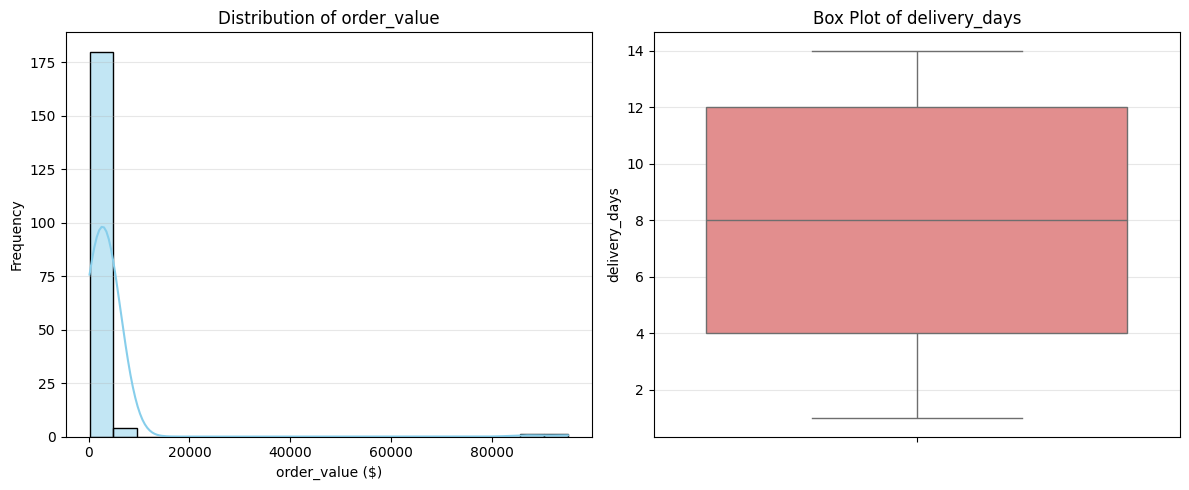

In [12]:
#Task 2 — Summarize & Visualize
#Plot a histogram for the order_value column to visualize its distribution.
#Plot a box plot for the delivery_days column to inspect for outliers.
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
sns.histplot(df['order_value'], bins=20, kde=True, color='skyblue')
plt.xlabel('order_value ($)')
plt.ylabel('Frequency')
plt.title('Distribution of order_value')
plt.grid(axis='y', alpha=0.3)

plt.subplot(1, 2, 2)
sns.boxplot(y=df['delivery_days'], color='lightcoral')
plt.ylabel('delivery_days')
plt.title('Box Plot of delivery_days')
plt.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()


In [16]:
#Task 3 — Correlation Analysis
#Compute the correlation matrix for all numerical columns using df.corr().
#select only numeric columns for correlation

numeric_df=df.select_dtypes(include=['float64', 'int64'])#only includes numaric columns
#compute correlation matrix
corr_matrix=numeric_df.corr()
print(corr_matrix)

               order_id  order_value  delivery_days
order_id       1.000000    -0.095503       0.004858
order_value   -0.095503     1.000000       0.141660
delivery_days  0.004858     0.141660       1.000000


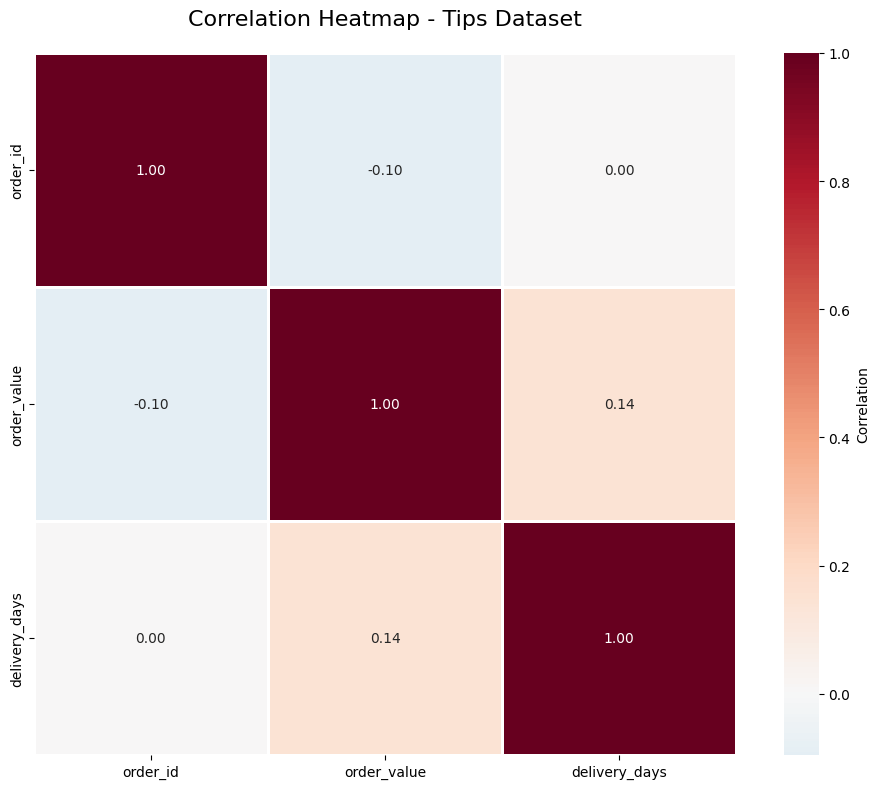


Key Correlations:
order_id     vs order_value : -0.096
order_id     vs delivery_days:  0.005
order_value  vs delivery_days:  0.142


In [17]:
#Task 3 — Correlation Analysis
#Plot a heatmap of the correlation matrix with annotation values visible inside each cell.

# Select numerical columns
numerical_cols = ['order_id', 'order_value', 'delivery_days']
correlation_matrix = df[numerical_cols].corr()

# Create heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, fmt='.2f',
            cmap='RdBu_r', center=0, square=True,
            linewidths=2, cbar_kws={'label': 'Correlation'})
plt.title('Correlation Heatmap - Tips Dataset', fontsize=16, pad=20)
plt.tight_layout()
plt.show()

print("\nKey Correlations:")
print("="*50)
for i in range(len(numerical_cols)):
    for j in range(i+1, len(numerical_cols)):
        corr_val = correlation_matrix.iloc[i, j]
        print(f"{numerical_cols[i]:12} vs {numerical_cols[j]:12}: {corr_val:6.3f}")

        #order_value  vs delivery_days slight postive
        #order_id     vs order_value slight negative